<a href="https://colab.research.google.com/github/ranjetmahato416/-Lung-CT-Image-Classification-Using-Public-Medical-Imaging-Data-/blob/main/Desktop/Colab_Notebook/Notebook/Notebook_14_Grad_CAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 14 — Grad-CAM Explainability for Fine-Tuned EfficientNetB0

This notebook applies Gradient-weighted Class Activation Mapping (Grad-CAM) to the final selected EfficientNetB0 model.

The model was selected because it achieved the highest test PR-AUC among EfficientNetB0, DenseNet121 and ResNet50.

Grad-CAM is used to identify image regions that contributed most strongly to malignant predictions. Examples are generated for:

- true positives;
- true negatives;
- false positives;
- false negatives.

The Grad-CAM outputs are intended for qualitative interpretation and do not constitute clinical validation.

##2. Imports

In [107]:
from pathlib import Path

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from PIL import Image

##3. mount Google drive

In [108]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##4. Define paths

In [109]:
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Dissertation"
)

EFFICIENTNET_ROOT = (
    PROJECT_ROOT
    / "Models"
    / "EfficientNetB0_FineTune_Last30"
)

MODEL_PATH = (
    EFFICIENTNET_ROOT
    / "best_model.keras"
)

TEST_PREDICTIONS_PATH = (
    EFFICIENTNET_ROOT
    / "test_predictions.csv"
)

TEST_CSV_PATH = (
    PROJECT_ROOT
    / "Dataset"
    / "Processed"
    / "test.csv"
)

GRADCAM_ROOT = (
    PROJECT_ROOT
    / "Models"
    / "Model_Comparison"
    / "GradCAM_EfficientNetB0"
)

GRADCAM_IMAGES_DIR = (
    GRADCAM_ROOT
    / "images"
)

GRADCAM_IMAGES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Model exists:", MODEL_PATH.exists())
print("Test CSV exists:", TEST_CSV_PATH.exists())
print("Grad-CAM output:", GRADCAM_ROOT)

Model exists: True
Test CSV exists: True
Grad-CAM output: /content/drive/MyDrive/Dissertation/Models/Model_Comparison/GradCAM_EfficientNetB0


##5. Load Final model selection

In [110]:
FINAL_SELECTION_PATH = (
    PROJECT_ROOT
    / "Models"
    / "Model_Comparison"
    / "final_model_selection.json"
)

with open(
    FINAL_SELECTION_PATH,
    "r"
) as file:

    final_selection = json.load(file)

print(final_selection)

{'FinalArchitecture': 'EfficientNetB0', 'SelectedConfiguration': 'Fine-Tuned EfficientNetB0', 'PrimarySelectionMetric': 'Test PR-AUC', 'TestROCAUC': 0.8302521008403362, 'TestPRAUC': 0.6337360925330153}


In [111]:
# Validate the architecture #

assert (
    final_selection["FinalArchitecture"]
    == "EfficientNetB0"
)

print(
    "Confirmed final model:",
    final_selection["FinalArchitecture"]
)

Confirmed final model: EfficientNetB0


##6. Load the test split

In [112]:
test_df = pd.read_csv(
    TEST_CSV_PATH
)

print("Test samples:", len(test_df))
print(test_df.columns.tolist())

display(test_df.head())

Test samples: 256
['PatientID', 'NoduleID', 'CancerLabel', 'LabelName', 'ImagePath']


,PatientID,NoduleID,CancerLabel,LabelName,ImagePath
0,LIDC-IDRI-0014,1,0,Benign,/content/drive/MyDrive/Dissertation/Dataset/Pr...
1,LIDC-IDRI-0018,1,0,Benign,/content/drive/MyDrive/Dissertation/Dataset/Pr...
2,LIDC-IDRI-0018,2,0,Benign,/content/drive/MyDrive/Dissertation/Dataset/Pr...
3,LIDC-IDRI-0018,3,0,Benign,/content/drive/MyDrive/Dissertation/Dataset/Pr...
4,LIDC-IDRI-0018,4,1,Malignant,/content/drive/MyDrive/Dissertation/Dataset/Pr...


In [113]:
# Confirm the required columns #

required_columns = [
    "ImagePath",
    "CancerLabel"
]

missing_columns = [
    column
    for column in required_columns
    if column not in test_df.columns
]

if missing_columns:

    raise ValueError(
        f"Missing columns: {missing_columns}"
    )

##7. Load the EfficientNet model

In [114]:
efficientnet_model = tf.keras.models.load_model(
    MODEL_PATH,
    compile=False
)

print(
    "Loaded EfficientNet model:",
    MODEL_PATH
)

print(
    "Input shape:",
    efficientnet_model.input_shape
)

print(
    "Output shape:",
    efficientnet_model.output_shape
)

Loaded EfficientNet model: /content/drive/MyDrive/Dissertation/Models/EfficientNetB0_FineTune_Last30/best_model.keras
Input shape: (None, 128, 128, 3)
Output shape: (None, 1)


In [115]:
# @tf.keras.utils.register_keras_serializable(
#     package="LungNoduleClassification"
# )
# class EfficientNetPreprocessing(
#     tf.keras.layers.Layer
# ):

#     def call(self, inputs):
#         return inputs

#     def get_config(self):
#         return super().get_config()

##8. Inspect model layers

In [116]:
for index, layer in enumerate(
    efficientnet_model.layers
):

    print(
        index,
        layer.name,
        layer.__class__.__name__,
        getattr(
            layer,
            "output_shape",
            "N/A"
        )
    )

0 input_layer_2 InputLayer N/A
1 efficientnetb0 Functional (None, 4, 4, 1280)
2 global_average_pooling2d GlobalAveragePooling2D N/A
3 dropout Dropout N/A
4 dense Dense N/A
5 dropout_1 Dropout N/A
6 dense_1 Dense N/A


In [117]:
nested_models = [
    layer
    for layer in efficientnet_model.layers
    if isinstance(
        layer,
        tf.keras.Model
    )
]

print(
    "Nested models:",
    [
        layer.name
        for layer in nested_models
    ]
)

Nested models: ['efficientnetb0']


In [118]:
efficientnet_backbone_candidates = [
    layer
    for layer in efficientnet_model.layers

    if (
        isinstance(
            layer,
            tf.keras.Model
        )

        and "efficientnet" in layer.name.lower()
    )
]

if len(
    efficientnet_backbone_candidates
) != 1:

    raise ValueError(
        "Could not identify exactly one "
        "EfficientNet backbone."
    )

efficientnet_backbone = (
    efficientnet_backbone_candidates[0]
)

print(
    "Backbone:",
    efficientnet_backbone.name
)

print(
    "Backbone layers:",
    len(
        efficientnet_backbone.layers
    )
)


Backbone: efficientnetb0
Backbone layers: 238


##9. Identify the final convolutional layer

In [119]:
convolutional_layers = [
    layer
    for layer in efficientnet_backbone.layers

    if isinstance(
        layer,
        tf.keras.layers.Conv2D
    )
]

print(
    "Last convolutional layers:"
)

for layer in convolutional_layers[-10:]:

    print(
        layer.name,
        layer.output.shape
    )

Last convolutional layers:
block6c_project_conv (None, 4, 4, 192)
block6d_expand_conv (None, 4, 4, 1152)
block6d_se_reduce (None, 1, 1, 48)
block6d_se_expand (None, 1, 1, 1152)
block6d_project_conv (None, 4, 4, 192)
block7a_expand_conv (None, 4, 4, 1152)
block7a_se_reduce (None, 1, 1, 48)
block7a_se_expand (None, 1, 1, 1152)
block7a_project_conv (None, 4, 4, 320)
top_conv (None, 4, 4, 1280)


In [120]:
LAST_CONV_LAYER_NAME = (
    convolutional_layers[-1].name
)

print(
    "Selected Grad-CAM layer:",
    LAST_CONV_LAYER_NAME
)

Selected Grad-CAM layer: top_conv


##10. Image loading function

In [121]:
IMAGE_SIZE = (
    128,
    128
)

def load_single_image(
    image_path
):

    image_bytes = tf.io.read_file(
        image_path
    )

    image = tf.image.decode_png(
        image_bytes,
        channels=3
    )

    image = tf.image.resize(
        image,
        IMAGE_SIZE,
        method=tf.image.ResizeMethod.BILINEAR
    )

    image = tf.cast(
        image,
        tf.float32
    )

    return image

##11. Test one prediction

In [122]:
sample_path = (
    test_df.loc[
        0,
        "ImagePath"
    ]
)

sample_image = load_single_image(
    sample_path
)

sample_batch = tf.expand_dims(
    sample_image,
    axis=0
)

sample_probability = float(
    efficientnet_model.predict(
        sample_batch,
        verbose=0
    )[0, 0]
)

print(
    "Sample probability:",
    sample_probability
)

print(
    "True label:",
    test_df.loc[
        0,
        "CancerLabel"
    ]
)

Sample probability: 0.5016864538192749
True label: 0


##12. Inspect the EfficientNet backbone

In [123]:
print("Backbone:", efficientnet_backbone.name)
print("Backbone input:", efficientnet_backbone.input_shape)
print("Backbone output:", efficientnet_backbone.output_shape)

conv_layers = [
    layer
    for layer in efficientnet_backbone.layers
    if isinstance(layer, tf.keras.layers.Conv2D)
]

print("\nLast 10 Conv2D layers:")

for layer in conv_layers[-10:]:
    print(
        layer.name,
        layer.output.shape
    )

LAST_CONV_LAYER_NAME = conv_layers[-1].name

print(
    "\nSelected Grad-CAM layer:",
    LAST_CONV_LAYER_NAME
)

Backbone: efficientnetb0
Backbone input: (None, 128, 128, 3)
Backbone output: (None, 4, 4, 1280)

Last 10 Conv2D layers:
block6c_project_conv (None, 4, 4, 192)
block6d_expand_conv (None, 4, 4, 1152)
block6d_se_reduce (None, 1, 1, 48)
block6d_se_expand (None, 1, 1, 1152)
block6d_project_conv (None, 4, 4, 192)
block7a_expand_conv (None, 4, 4, 1152)
block7a_se_reduce (None, 1, 1, 48)
block7a_se_expand (None, 1, 1, 1152)
block7a_project_conv (None, 4, 4, 320)
top_conv (None, 4, 4, 1280)

Selected Grad-CAM layer: top_conv


##13. Build a feature extractor

In [124]:
last_conv_layer = (
    efficientnet_backbone.get_layer(
        LAST_CONV_LAYER_NAME
    )
)

backbone_feature_extractor = tf.keras.Model(
    inputs=efficientnet_backbone.input,
    outputs=[
        last_conv_layer.output,
        efficientnet_backbone.output
    ],
    name="efficientnet_gradcam_extractor"
)

print(
    "Feature extractor created."
)

print(
    "Conv output:",
    backbone_feature_extractor.output[0].shape
)

print(
    "Backbone output:",
    backbone_feature_extractor.output[1].shape
)

Feature extractor created.
Conv output: (None, 4, 4, 1280)
Backbone output: (None, 4, 4, 1280)


##14. Determine the outer-model structure

In [125]:
print("=" * 70)
print("OUTER MODEL STRUCTURE")
print("=" * 70)

for i, layer in enumerate(
    efficientnet_model.layers
):

    print(
        f"{i:02d}",
        "|",
        layer.name,
        "|",
        layer.__class__.__name__
    )

OUTER MODEL STRUCTURE
00 | input_layer_2 | InputLayer
01 | efficientnetb0 | Functional
02 | global_average_pooling2d | GlobalAveragePooling2D
03 | dropout | Dropout
04 | dense | Dense
05 | dropout_1 | Dropout
06 | dense_1 | Dense


In [126]:
# Locate the backbone index automatically #

BACKBONE_INDEX = (
    efficientnet_model.layers.index(
        efficientnet_backbone
    )
)

print(
    "EfficientNet backbone index:",
    BACKBONE_INDEX
)

print("\nLayers before backbone:")

for layer in efficientnet_model.layers[
    1:BACKBONE_INDEX
]:

    print(
        layer.name,
        layer.__class__.__name__
    )

print("\nLayers after backbone:")

for layer in efficientnet_model.layers[
    BACKBONE_INDEX + 1:
]:

    print(
        layer.name,
        layer.__class__.__name__
    )

EfficientNet backbone index: 1

Layers before backbone:

Layers after backbone:
global_average_pooling2d GlobalAveragePooling2D
dropout Dropout
dense Dense
dropout_1 Dropout
dense_1 Dense


##15. Grad-CAM function

In [127]:
def make_gradcam_heatmap(
    image_batch,
    model,
    backbone,
    feature_extractor,
    target_class=1
):

    backbone_index = (
        model.layers.index(
            backbone
        )
    )

    # --------------------------------------------------
    # Forward pass through layers BEFORE EfficientNet
    # --------------------------------------------------

    x = image_batch

    for layer in model.layers[
        1:backbone_index
    ]:

        # Important:
        # Disable augmentation during Grad-CAM inference.
        try:
            x = layer(
                x,
                training=False
            )

        except TypeError:
            x = layer(x)

    # --------------------------------------------------
    # EfficientNet feature extraction
    # --------------------------------------------------

    with tf.GradientTape() as tape:

        conv_outputs, backbone_output = (
            feature_extractor(
                x,
                training=False
            )
        )

        tape.watch(
            conv_outputs
        )

        # ----------------------------------------------
        # Continue through classifier layers
        # AFTER EfficientNet
        # ----------------------------------------------

        y = backbone_output

        for layer in model.layers[
            backbone_index + 1:
        ]:

            try:
                y = layer(
                    y,
                    training=False
                )

            except TypeError:
                y = layer(y)

        # Binary sigmoid output
        malignant_probability = y[:, 0]

        if target_class == 1:
            target_score = malignant_probability

        elif target_class == 0:
            target_score = 1.0 - malignant_probability

        else:
            raise ValueError(
                "target_class must be 0 (Benign) "
                "or 1 (Malignant)."
            )

    # --------------------------------------------------
    # Gradient of malignant probability
    # with respect to final conv features
    # --------------------------------------------------

    gradients = tape.gradient(
    target_score,
    conv_outputs
    )

    if gradients is None:

        raise RuntimeError(
            "Gradients are None. "
            "The convolutional features are not "
            "connected to the prediction."
        )

    # --------------------------------------------------
    # Global-average-pool gradients
    # --------------------------------------------------

    pooled_gradients = tf.reduce_mean(
        gradients,
        axis=(0, 1, 2)
    )

    # Remove batch dimension
    conv_outputs = conv_outputs[0]

    # --------------------------------------------------
    # Weighted feature-map combination
    # --------------------------------------------------

    heatmap = tf.reduce_sum(
        conv_outputs
        * pooled_gradients,
        axis=-1
    )

    # Standard Grad-CAM ReLU
    heatmap = tf.maximum(
        heatmap,
        0
    )

    # --------------------------------------------------
    # Normalize to [0, 1]
    # --------------------------------------------------

    max_value = tf.reduce_max(
        heatmap
    )

    if max_value > 0:

        heatmap = (
            heatmap
            / max_value
        )

    return heatmap.numpy()

##16. Generate the test heatmap

In [128]:
sample_heatmap = make_gradcam_heatmap(
    image_batch=sample_batch,
    model=efficientnet_model,
    backbone=efficientnet_backbone,
    feature_extractor=backbone_feature_extractor
)

print(
    "Heatmap shape:",
    sample_heatmap.shape
)

print(
    "Heatmap minimum:",
    sample_heatmap.min()
)

print(
    "Heatmap maximum:",
    sample_heatmap.max()
)

Heatmap shape: (4, 4)
Heatmap minimum: 0.0
Heatmap maximum: 1.0


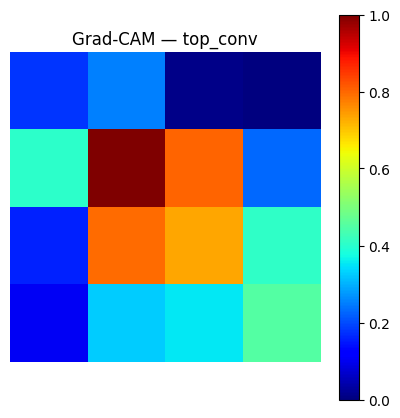

In [129]:
plt.figure(figsize=(5, 5))

plt.imshow(
    sample_heatmap,
    cmap="jet"
)

plt.colorbar()

plt.title(
    f"Grad-CAM — {LAST_CONV_LAYER_NAME}"
)

plt.axis("off")

plt.show()

##17. Create Grad-CAM overlay function

In [130]:
# ============================================================
# Grad-CAM Overlay Function
# ============================================================

def create_gradcam_overlay(
    image,
    heatmap,
    alpha=0.4
):

    # Convert image tensor to numpy
    image_array = image.numpy().astype(np.float32)

    # Normalize original image to [0, 1]
    image_min = image_array.min()
    image_max = image_array.max()

    image_normalized = (
        image_array - image_min
    ) / (
        image_max - image_min + 1e-8
    )

    # Resize heatmap to image size
    resized_heatmap = tf.image.resize(
        heatmap[..., np.newaxis],
        IMAGE_SIZE,
        method="bilinear"
    ).numpy()

    resized_heatmap = np.squeeze(
        resized_heatmap
    )

    # Apply colour map
    colormap = plt.get_cmap("jet")

    heatmap_rgb = colormap(
        resized_heatmap
    )[:, :, :3]

    # Blend heatmap with original image
    overlay = (
        (1 - alpha) * image_normalized
        + alpha * heatmap_rgb
    )

    overlay = np.clip(
        overlay,
        0,
        1
    )

    return (
        image_normalized,
        resized_heatmap,
        overlay
    )

##18. Visualize the sample Grad-CAM

In [131]:
# ============================================================
# Visualize Sample Grad-CAM
# ============================================================

sample_original, \
sample_resized_heatmap, \
sample_overlay = create_gradcam_overlay(
    image=sample_image,
    heatmap=sample_heatmap,
    alpha=0.4
)

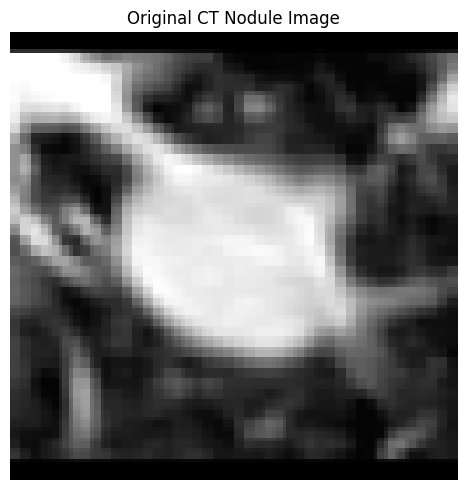

In [132]:
plt.figure(figsize=(5, 5))

plt.imshow(
    sample_original
)

plt.title(
    "Original CT Nodule Image"
)

plt.axis("off")
plt.tight_layout()
plt.show()

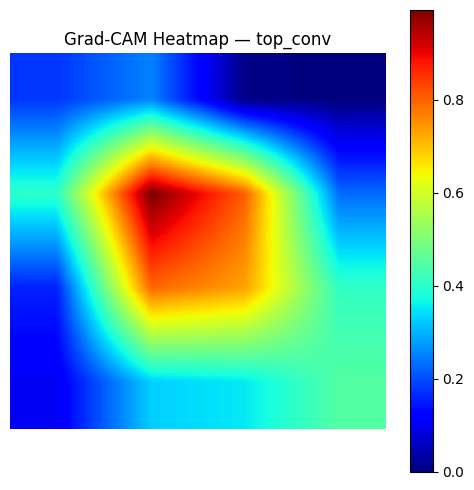

In [133]:
plt.figure(figsize=(5, 5))

plt.imshow(
    sample_resized_heatmap,
    cmap="jet"
)

plt.title(
    f"Grad-CAM Heatmap — {LAST_CONV_LAYER_NAME}"
)

plt.axis("off")
plt.colorbar()
plt.tight_layout()
plt.show()

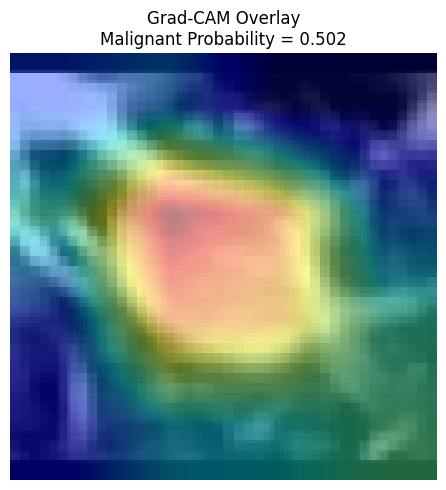

In [134]:
plt.figure(figsize=(5, 5))

plt.imshow(
    sample_overlay
)

plt.title(
    f"Grad-CAM Overlay\n"
    f"Malignant Probability = {sample_probability:.3f}"
)

plt.axis("off")
plt.tight_layout()
plt.show()

##19. Load EfficientNet summary and threshold

In [135]:
# ============================================================
# Load EfficientNet Summary
# ============================================================

EFFICIENTNET_SUMMARY_PATH = (
    EFFICIENTNET_ROOT
    / "model_summary.csv"
)

efficientnet_summary = pd.read_csv(
    EFFICIENTNET_SUMMARY_PATH
)

display(
    efficientnet_summary
)

,SelectedModel,ValidationROC_AUC,ValidationPR_AUC,TestROC_AUC,TestPR_AUC,DefaultThreshold,ValidationF1Threshold,HighRecallThreshold
0,Fine-Tuned EfficientNetB0,0.850649,0.570277,0.830252,0.633736,0.5,0.464395,0.327528


In [136]:
EFFICIENTNET_DEFAULT_THRESHOLD = float(
    efficientnet_summary.loc[
        0,
        "DefaultThreshold"
    ]
)

EFFICIENTNET_F1_THRESHOLD = float(
    efficientnet_summary.loc[
        0,
        "ValidationF1Threshold"
    ]
)

EFFICIENTNET_HIGH_RECALL_THRESHOLD = float(
    efficientnet_summary.loc[
        0,
        "HighRecallThreshold"
    ]
)

print(
    "Default threshold:",
    EFFICIENTNET_DEFAULT_THRESHOLD
)

print(
    "Validation F1 threshold:",
    EFFICIENTNET_F1_THRESHOLD
)

print(
    "High-recall threshold:",
    EFFICIENTNET_HIGH_RECALL_THRESHOLD
)

Default threshold: 0.5
Validation F1 threshold: 0.46439537
High-recall threshold: 0.32752764


##20. Generate EfficientNet predictions for the test split

In [137]:
# ============================================================
# Generate Test Predictions
# ============================================================

test_probabilities = []

for index, image_path in enumerate(
    test_df["ImagePath"]
):

    image = load_single_image(
        image_path
    )

    image_batch = tf.expand_dims(
        image,
        axis=0
    )

    probability = float(
        efficientnet_model.predict(
            image_batch,
            verbose=0
        )[0, 0]
    )

    test_probabilities.append(
        probability
    )

    if (
        (index + 1) % 50 == 0
        or index == len(test_df) - 1
    ):

        print(
            f"Processed "
            f"{index + 1}/{len(test_df)}"
        )

Processed 50/256
Processed 100/256
Processed 150/256
Processed 200/256
Processed 250/256
Processed 256/256


In [138]:
gradcam_test_df = test_df.copy()

gradcam_test_df[
    "PredictedProbability"
] = test_probabilities

display(
    gradcam_test_df.head()
)

,PatientID,NoduleID,CancerLabel,LabelName,ImagePath,PredictedProbability
0,LIDC-IDRI-0014,1,0,Benign,/content/drive/MyDrive/Dissertation/Dataset/Pr...,0.501686
1,LIDC-IDRI-0018,1,0,Benign,/content/drive/MyDrive/Dissertation/Dataset/Pr...,0.219640
2,LIDC-IDRI-0018,2,0,Benign,/content/drive/MyDrive/Dissertation/Dataset/Pr...,0.152955
3,LIDC-IDRI-0018,3,0,Benign,/content/drive/MyDrive/Dissertation/Dataset/Pr...,0.191848
4,LIDC-IDRI-0018,4,1,Malignant,/content/drive/MyDrive/Dissertation/Dataset/Pr...,0.765834


##21. Apply the validation-selected F1 threshold

In [139]:
# ============================================================
# Apply Validation-Selected Threshold
# ============================================================

gradcam_test_df[
    "PredictedLabel"
] = (
    gradcam_test_df[
        "PredictedProbability"
    ]
    >= EFFICIENTNET_F1_THRESHOLD
).astype(int)

print(
    gradcam_test_df[
        "PredictedLabel"
    ]
    .value_counts()
    .sort_index()
)

PredictedLabel
0    220
1     36
Name: count, dtype: int64


##22. Categorize TP, TN, FP and FN

In [140]:
# ============================================================
# Categorize Prediction Outcomes
# ============================================================

def assign_prediction_outcome(row):

    true_label = int(
        row["CancerLabel"]
    )

    predicted_label = int(
        row["PredictedLabel"]
    )

    if (
        true_label == 1
        and predicted_label == 1
    ):
        return "True Positive"

    elif (
        true_label == 0
        and predicted_label == 0
    ):
        return "True Negative"

    elif (
        true_label == 0
        and predicted_label == 1
    ):
        return "False Positive"

    else:
        return "False Negative"

In [141]:
gradcam_test_df[
    "Outcome"
] = gradcam_test_df.apply(
    assign_prediction_outcome,
    axis=1
)

outcome_counts = (
    gradcam_test_df[
        "Outcome"
    ]
    .value_counts()
)

display(
    outcome_counts
)

,count
Outcome,
True Negative,205
True Positive,20
False Positive,16
False Negative,15


In [142]:
outcome_summary = (
    gradcam_test_df[
        "Outcome"
    ]
    .value_counts()
    .rename_axis(
        "Outcome"
    )
    .reset_index(
        name="Count"
    )
)

display(
    outcome_summary
)

,Outcome,Count
0,True Negative,205
1,True Positive,20
2,False Positive,16
3,False Negative,15


##23. Select High-Confidence Grad-CAM Examples

###Panel A. High-Confidence TP/FP/TN/FN

In [143]:
# ============================================================
# Select Representative Cases
# ============================================================

NUMBER_PER_GROUP = 3

selected_case_frames = []

outcome_order = [
    "True Positive",
    "True Negative",
    "False Positive",
    "False Negative"
]

for outcome in outcome_order:

    subset = gradcam_test_df[
        gradcam_test_df[
            "Outcome"
        ] == outcome
    ].copy()

    if outcome in [
        "True Positive",
        "False Positive"
    ]:

        subset = subset.sort_values(
            by="PredictedProbability",
            ascending=False
        )

    else:

        subset = subset.sort_values(
            by="PredictedProbability",
            ascending=True
        )

    selected_subset = subset.head(
        NUMBER_PER_GROUP
    )

    selected_case_frames.append(
        selected_subset
    )

In [144]:
selected_cases_df = pd.concat(
    selected_case_frames,
    ignore_index=True
)

display(
    selected_cases_df[
        [
            "ImagePath",
            "CancerLabel",
            "PredictedProbability",
            "PredictedLabel",
            "Outcome"
        ]
    ]
)

,ImagePath,CancerLabel,PredictedProbability,PredictedLabel,Outcome
0,/content/drive/MyDrive/Dissertation/Dataset/Pr...,1,0.995135,1,True Positive
1,/content/drive/MyDrive/Dissertation/Dataset/Pr...,1,0.988083,1,True Positive
2,/content/drive/MyDrive/Dissertation/Dataset/Pr...,1,0.982160,1,True Positive
3,/content/drive/MyDrive/Dissertation/Dataset/Pr...,0,0.030229,0,True Negative
4,/content/drive/MyDrive/Dissertation/Dataset/Pr...,0,0.035126,0,True Negative
5,/content/drive/MyDrive/Dissertation/Dataset/Pr...,0,0.046444,0,True Negative
6,/content/drive/MyDrive/Dissertation/Dataset/Pr...,0,0.920843,1,False Positive
7,/content/drive/MyDrive/Dissertation/Dataset/Pr...,0,0.839977,1,False Positive
8,/content/drive/MyDrive/Dissertation/Dataset/Pr...,0,0.750480,1,False Positive
9,/content/drive/MyDrive/Dissertation/Dataset/Pr...,1,0.044554,0,False Negative


###Panel B — typical TP/TN/FP/FN nearest to the median probability of each group

In [145]:
typical_cases = []

for outcome in outcome_order:

    subset = gradcam_test_df[
        gradcam_test_df["Outcome"] == outcome
    ].copy()

    if len(subset) == 0:
        continue

    median_probability = (
        subset["PredictedProbability"]
        .median()
    )

    subset[
        "DistanceFromMedian"
    ] = abs(
        subset["PredictedProbability"]
        - median_probability
    )

    typical_cases.append(
        subset.sort_values(
            "DistanceFromMedian"
        ).iloc[0]
    )

typical_cases_df = pd.DataFrame(
    typical_cases
)

display(
    typical_cases_df[
        [
            "PatientID",
            "NoduleID",
            "CancerLabel",
            "PredictedProbability",
            "PredictedLabel",
            "Outcome"
        ]
    ]
)

,PatientID,NoduleID,CancerLabel,PredictedProbability,PredictedLabel,Outcome
15,LIDC-IDRI-0077,1,1,0.821455,1,True Positive
41,LIDC-IDRI-0149,5,0,0.202556,0,True Negative
236,LIDC-IDRI-0892,2,0,0.604059,1,False Positive
67,LIDC-IDRI-0223,3,1,0.286921,0,False Negative


##24. Add safe handling for missing groups

In [146]:
# ============================================================
# Check Selected Case Counts
# ============================================================

selected_counts = (
    selected_cases_df[
        "Outcome"
    ]
    .value_counts()
)

print(
    selected_counts
)

for outcome in outcome_order:

    count = selected_counts.get(
        outcome,
        0
    )

    if count < NUMBER_PER_GROUP:

        print(
            f"Warning: only {count} "
            f"{outcome} cases available."
        )

Outcome
True Positive     3
True Negative     3
False Positive    3
False Negative    3
Name: count, dtype: int64


##25. Create Grad-CAM output folders

In [156]:
# ============================================================
# Grad-CAM Output Directories
# ============================================================

GRADCAM_ROOT = (
    PROJECT_ROOT
    / "Models"
    / "Model_Comparison"
    / "GradCAM_EfficientNetB0"
)

GRADCAM_COMBINED_DIR = (
    GRADCAM_ROOT
    / "combined_figures"
)

GRADCAM_OVERLAY_DIR = (
    GRADCAM_ROOT
    / "overlay_only"
)

GRADCAM_HEATMAP_DIR = (
    GRADCAM_ROOT
    / "heatmaps"
)

for directory in [
    GRADCAM_ROOT,
    GRADCAM_COMBINED_DIR,
    GRADCAM_OVERLAY_DIR,
    GRADCAM_HEATMAP_DIR
]:

    directory.mkdir(
        parents=True,
        exist_ok=True
    )

print(
    "Grad-CAM output root:",
    GRADCAM_ROOT
)

Grad-CAM output root: /content/drive/MyDrive/Dissertation/Models/Model_Comparison/GradCAM_EfficientNetB0


##26. Generate all selected Grad-Cam examples

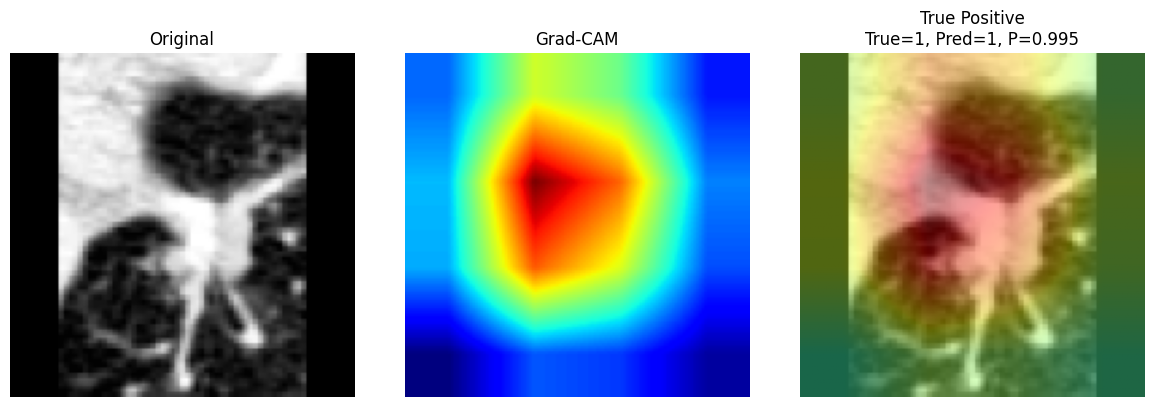

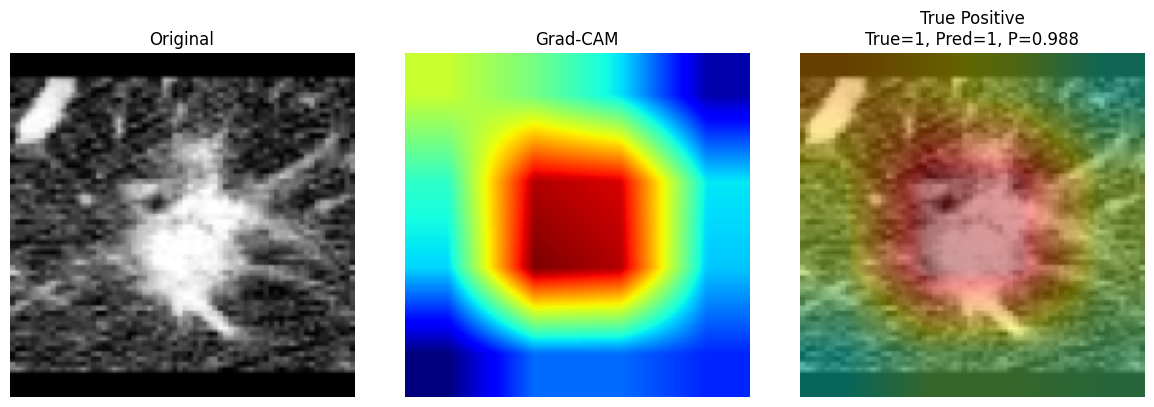

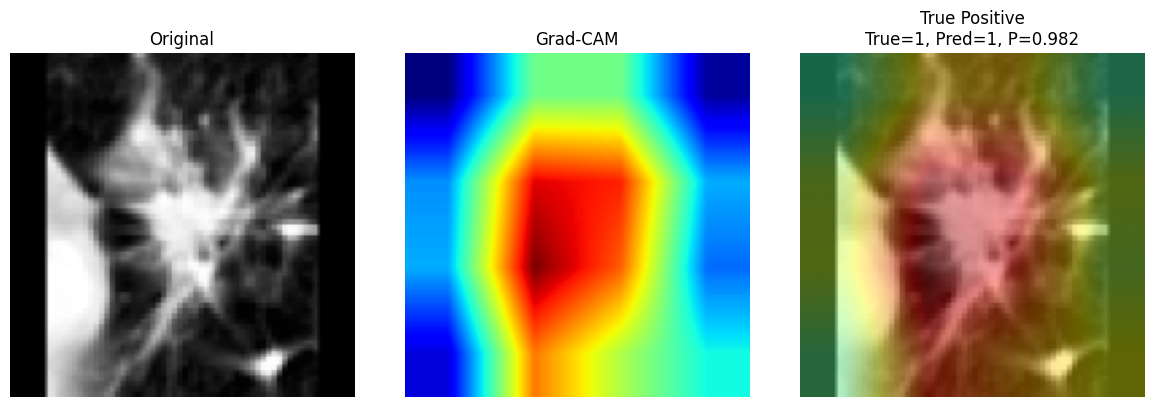

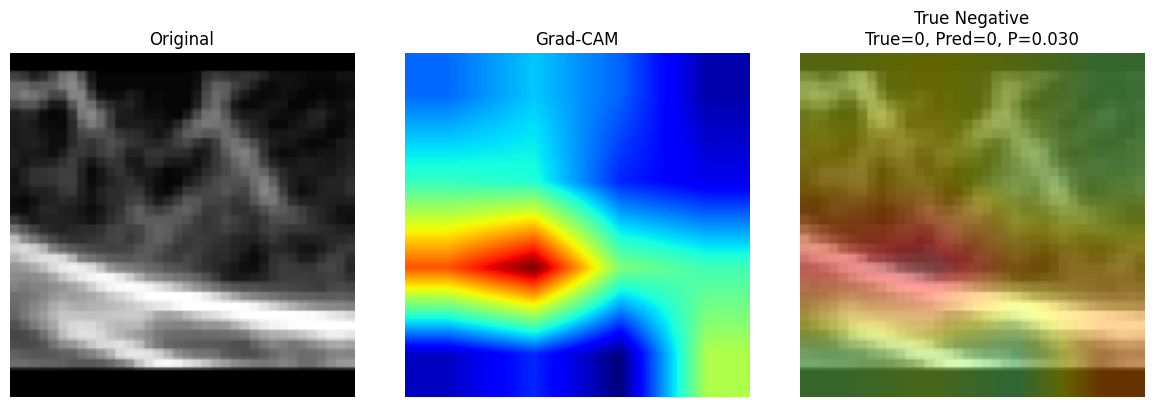

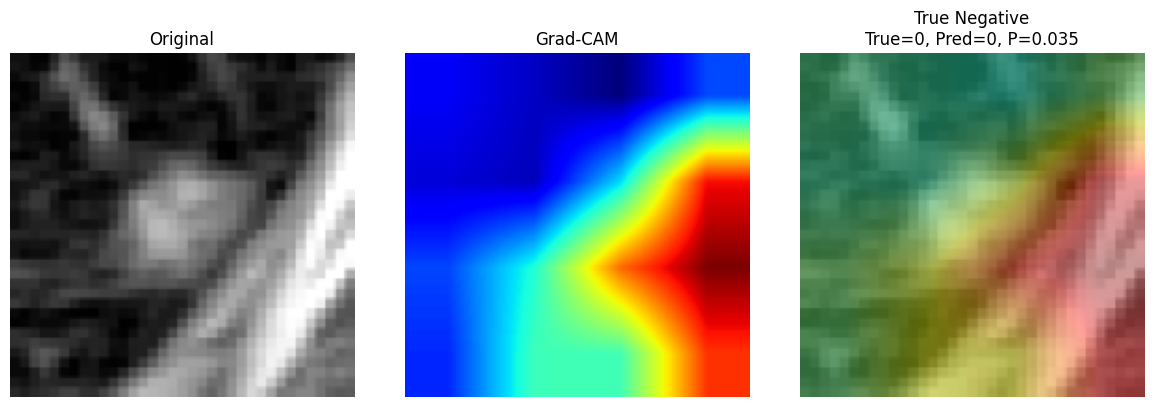

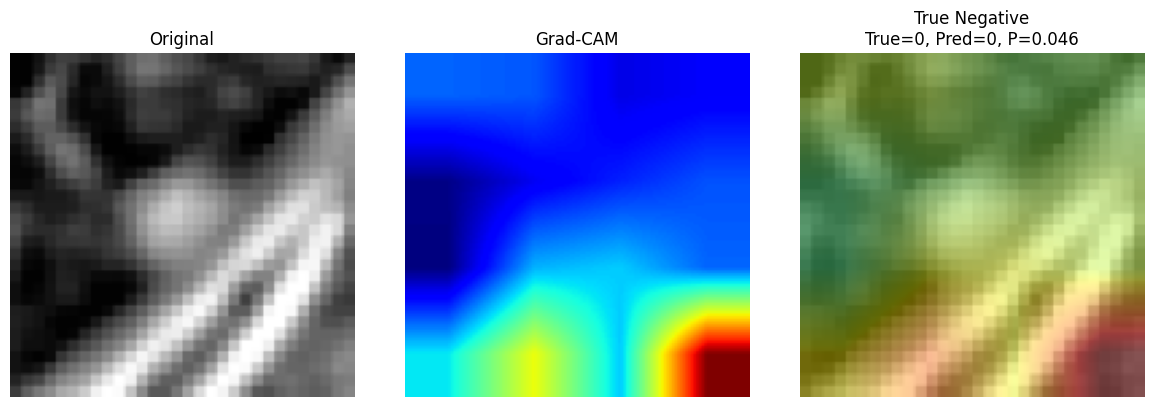

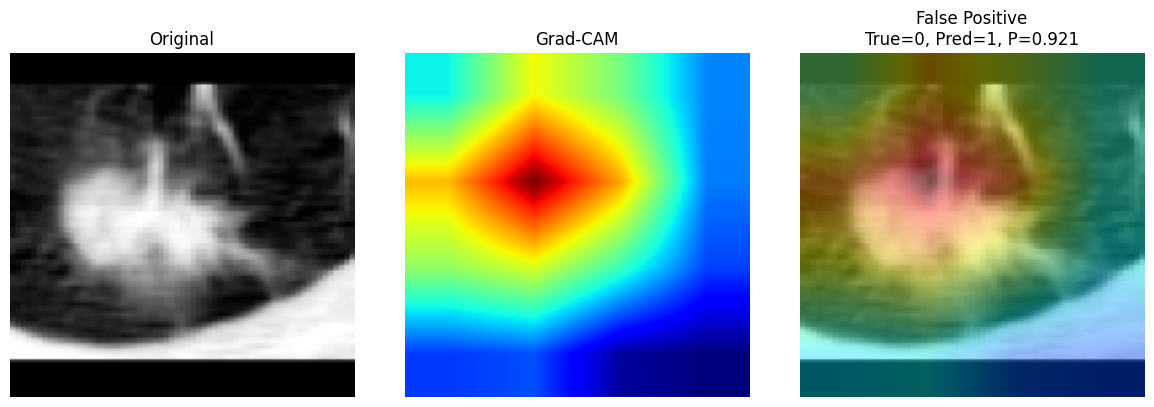

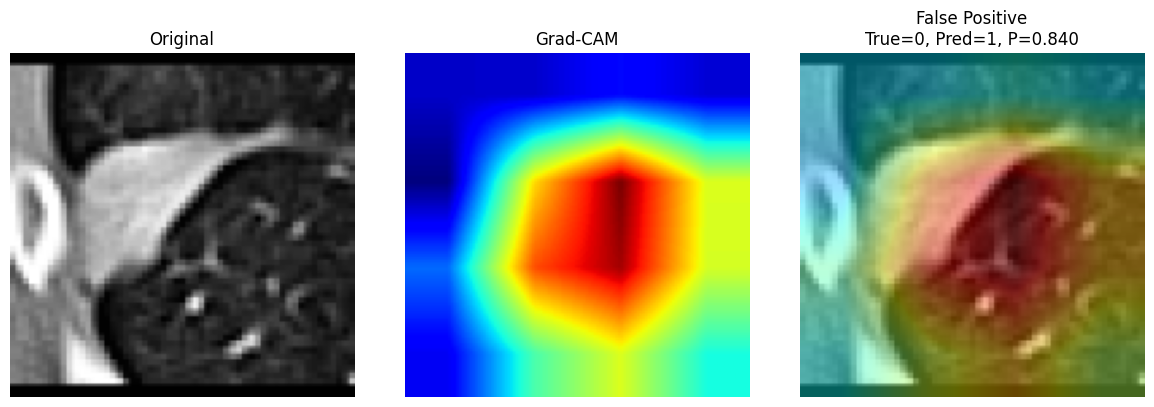

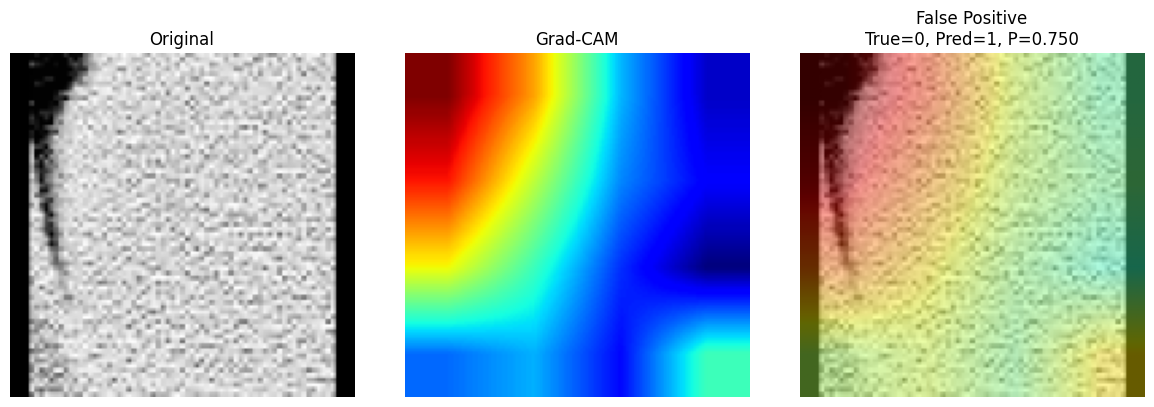

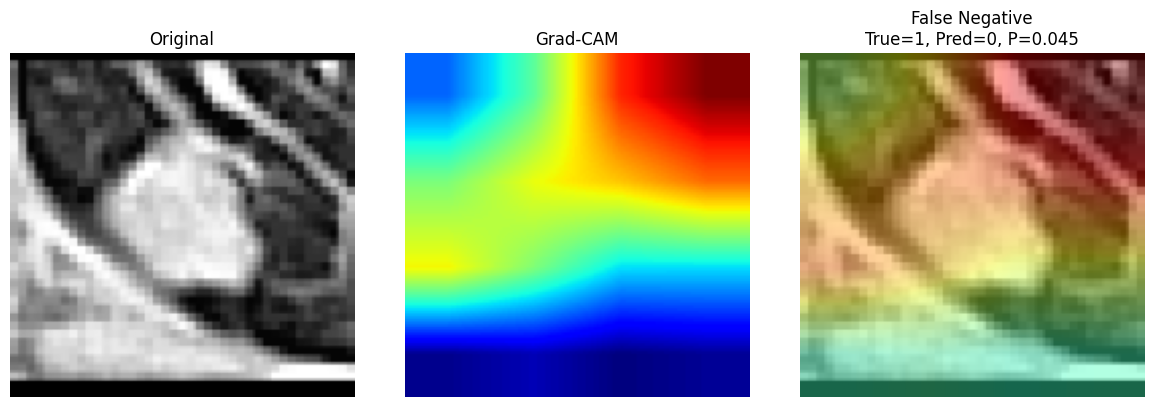

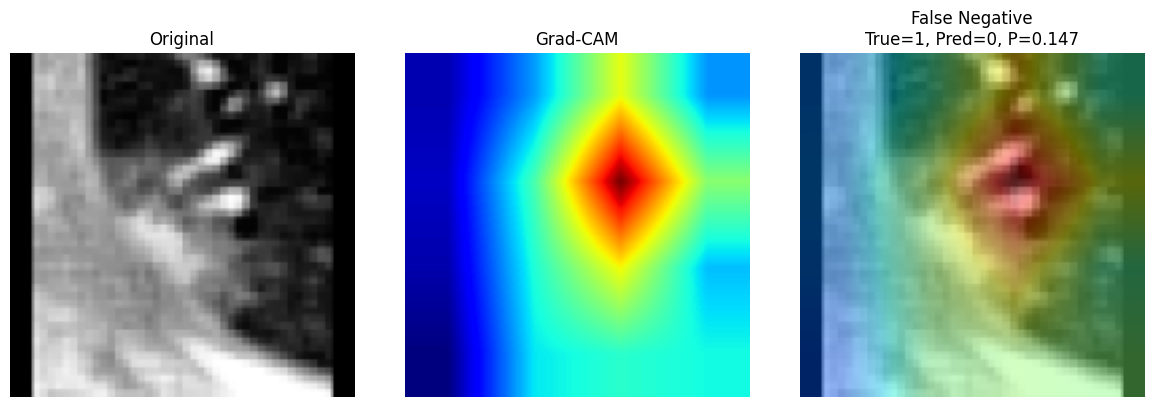

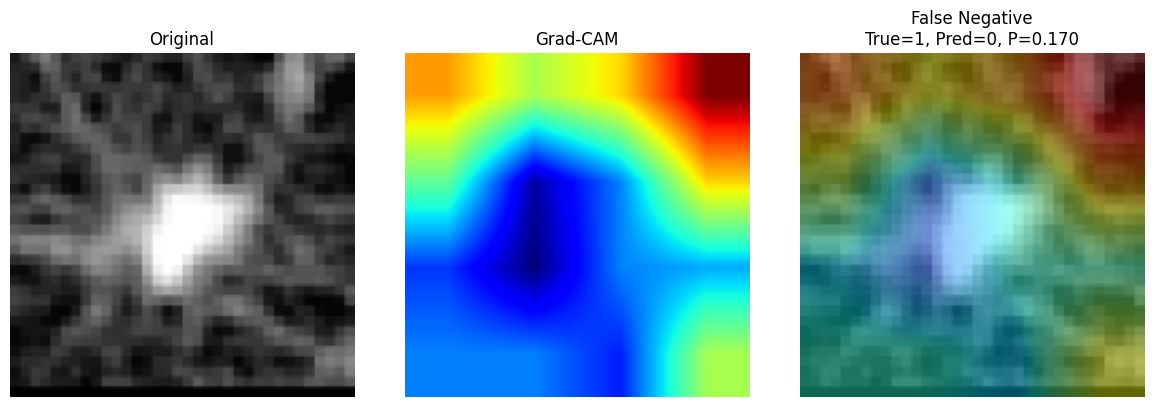

In [157]:
# ============================================================
# Generate Representative Grad-CAM Examples
# ============================================================

gradcam_records = []

for case_index, row in selected_cases_df.iterrows():

    image_path = row[
        "ImagePath"
    ]

    true_label = int(
        row[
            "CancerLabel"
        ]
    )

    predicted_label = int(
        row[
            "PredictedLabel"
        ]
    )

    probability = float(
        row[
            "PredictedProbability"
        ]
    )

    outcome = row[
        "Outcome"
    ]

    # --------------------------------------------
    # Load image
    # --------------------------------------------

    image = load_single_image(
        image_path
    )

    image_batch = tf.expand_dims(
        image,
        axis=0
    )

    # --------------------------------------------
    # Grad-CAM
    # --------------------------------------------

    heatmap = make_gradcam_heatmap(
    image_batch=image_batch,
    model=efficientnet_model,
    backbone=efficientnet_backbone,
    feature_extractor=backbone_feature_extractor,
    target_class=predicted_label
    )

    original, \
    resized_heatmap, \
    overlay = create_gradcam_overlay(
        image=image,
        heatmap=heatmap,
        alpha=0.4
    )

    # --------------------------------------------
    # Filename
    # --------------------------------------------

    outcome_slug = (
        outcome
        .lower()
        .replace(
            " ",
            "_"
        )
    )

    base_filename = (
        f"{outcome_slug}_"
        f"{case_index + 1:02d}"
    )

    combined_path = (
        GRADCAM_COMBINED_DIR
        / f"{base_filename}.png"
    )

    overlay_path = (
        GRADCAM_OVERLAY_DIR
        / f"{base_filename}.png"
    )

    heatmap_path = (
        GRADCAM_HEATMAP_DIR
        / f"{base_filename}.png"
    )

    # --------------------------------------------
    # Save combined figure
    # --------------------------------------------

    plt.figure(
        figsize=(12, 4)
    )

    plt.subplot(
        1,
        3,
        1
    )

    plt.imshow(
        original
    )

    plt.title(
        "Original"
    )

    plt.axis(
        "off"
    )

    plt.subplot(
        1,
        3,
        2
    )

    plt.imshow(
        resized_heatmap,
        cmap="jet"
    )

    plt.title(
        "Grad-CAM"
    )

    plt.axis(
        "off"
    )

    plt.subplot(
        1,
        3,
        3
    )

    plt.imshow(
        overlay
    )

    plt.title(
        f"{outcome}\n"
        f"True={true_label}, "
        f"Pred={predicted_label}, "
        f"P={probability:.3f}"
    )

    plt.axis(
        "off"
    )

    plt.tight_layout()

    plt.savefig(
        combined_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()

    # --------------------------------------------
    # Save overlay only
    # --------------------------------------------

    plt.figure(
        figsize=(5, 5)
    )

    plt.imshow(
        overlay
    )

    plt.axis(
        "off"
    )

    plt.tight_layout()

    plt.savefig(
        overlay_path,
        dpi=300,
        bbox_inches="tight",
        pad_inches=0
    )

    plt.close()

    # --------------------------------------------
    # Save heatmap only
    # --------------------------------------------

    plt.figure(
        figsize=(5, 5)
    )

    plt.imshow(
        resized_heatmap,
        cmap="jet"
    )

    plt.axis(
        "off"
    )

    plt.tight_layout()

    plt.savefig(
        heatmap_path,
        dpi=300,
        bbox_inches="tight",
        pad_inches=0
    )

    plt.close()

    # --------------------------------------------
    # Record metadata
    # --------------------------------------------

    gradcam_records.append(
        {
            "ImagePath":
                image_path,

            "Outcome":
                outcome,

            "TrueLabel":
                true_label,

            "PredictedLabel":
                predicted_label,

            "PredictedProbability":
                probability,

            "Threshold":
                EFFICIENTNET_F1_THRESHOLD,

            "GradCAMLayer":
                LAST_CONV_LAYER_NAME,

            "CombinedFigurePath":
                str(
                    combined_path
                ),

            "OverlayPath":
                str(
                    overlay_path
                ),

            "HeatmapPath":
                str(
                    heatmap_path
                )
        }
    )

##27. Save Grad-CAM metadata

In [158]:
# ============================================================
# Save Grad-CAM Metadata
# ============================================================

gradcam_metadata_df = pd.DataFrame(
    gradcam_records
)

GRADCAM_METADATA_PATH = (
    GRADCAM_ROOT
    / "gradcam_metadata.csv"
)

gradcam_metadata_df.to_csv(
    GRADCAM_METADATA_PATH,
    index=False
)

print(
    "Saved Grad-CAM metadata:"
)

print(
    GRADCAM_METADATA_PATH
)

display(
    gradcam_metadata_df
)

Saved Grad-CAM metadata:
/content/drive/MyDrive/Dissertation/Models/Model_Comparison/GradCAM_EfficientNetB0/gradcam_metadata.csv


,ImagePath,Outcome,TrueLabel,PredictedLabel,PredictedProbability,Threshold,GradCAMLayer,CombinedFigurePath,OverlayPath,HeatmapPath
0,/content/drive/MyDrive/Dissertation/Dataset/Pr...,True Positive,1,1,0.995135,0.464395,top_conv,/content/drive/MyDrive/Dissertation/Models/Mod...,/content/drive/MyDrive/Dissertation/Models/Mod...,/content/drive/MyDrive/Dissertation/Models/Mod...
1,/content/drive/MyDrive/Dissertation/Dataset/Pr...,True Positive,1,1,0.988083,0.464395,top_conv,/content/drive/MyDrive/Dissertation/Models/Mod...,/content/drive/MyDrive/Dissertation/Models/Mod...,/content/drive/MyDrive/Dissertation/Models/Mod...
2,/content/drive/MyDrive/Dissertation/Dataset/Pr...,True Positive,1,1,0.982160,0.464395,top_conv,/content/drive/MyDrive/Dissertation/Models/Mod...,/content/drive/MyDrive/Dissertation/Models/Mod...,/content/drive/MyDrive/Dissertation/Models/Mod...
3,/content/drive/MyDrive/Dissertation/Dataset/Pr...,True Negative,0,0,0.030229,0.464395,top_conv,/content/drive/MyDrive/Dissertation/Models/Mod...,/content/drive/MyDrive/Dissertation/Models/Mod...,/content/drive/MyDrive/Dissertation/Models/Mod...
4,/content/drive/MyDrive/Dissertation/Dataset/Pr...,True Negative,0,0,0.035126,0.464395,top_conv,/content/drive/MyDrive/Dissertation/Models/Mod...,/content/drive/MyDrive/Dissertation/Models/Mod...,/content/drive/MyDrive/Dissertation/Models/Mod...
5,/content/drive/MyDrive/Dissertation/Dataset/Pr...,True Negative,0,0,0.046444,0.464395,top_conv,/content/drive/MyDrive/Dissertation/Models/Mod...,/content/drive/MyDrive/Dissertation/Models/Mod...,/content/drive/MyDrive/Dissertation/Models/Mod...
6,/content/drive/MyDrive/Dissertation/Dataset/Pr...,False Positive,0,1,0.920843,0.464395,top_conv,/content/drive/MyDrive/Dissertation/Models/Mod...,/content/drive/MyDrive/Dissertation/Models/Mod...,/content/drive/MyDrive/Dissertation/Models/Mod...
7,/content/drive/MyDrive/Dissertation/Dataset/Pr...,False Positive,0,1,0.839977,0.464395,top_conv,/content/drive/MyDrive/Dissertation/Models/Mod...,/content/drive/MyDrive/Dissertation/Models/Mod...,/content/drive/MyDrive/Dissertation/Models/Mod...
8,/content/drive/MyDrive/Dissertation/Dataset/Pr...,False Positive,0,1,0.750480,0.464395,top_conv,/content/drive/MyDrive/Dissertation/Models/Mod...,/content/drive/MyDrive/Dissertation/Models/Mod...,/content/drive/MyDrive/Dissertation/Models/Mod...
9,/content/drive/MyDrive/Dissertation/Dataset/Pr...,False Negative,1,0,0.044554,0.464395,top_conv,/content/drive/MyDrive/Dissertation/Models/Mod...,/content/drive/MyDrive/Dissertation/Models/Mod...,/content/drive/MyDrive/Dissertation/Models/Mod...


##28. Save full test predictions used for Grad-CAM

In [159]:
# ============================================================
# Save Test Predictions Used for Explainability
# ============================================================

GRADCAM_TEST_PREDICTIONS_PATH = (
    GRADCAM_ROOT
    / "efficientnet_test_predictions_for_gradcam.csv"
)

gradcam_test_df.to_csv(
    GRADCAM_TEST_PREDICTIONS_PATH,
    index=False
)

print(
    "Saved Grad-CAM test predictions:"
)

print(
    GRADCAM_TEST_PREDICTIONS_PATH
)

Saved Grad-CAM test predictions:
/content/drive/MyDrive/Dissertation/Models/Model_Comparison/GradCAM_EfficientNetB0/efficientnet_test_predictions_for_gradcam.csv


##29. Create a Grad-CAM outcome summary

In [160]:
# ============================================================
# Grad-CAM Outcome Summary
# ============================================================

gradcam_outcome_summary = (
    gradcam_test_df
    .groupby(
        "Outcome"
    )
    .agg(
        Count=(
            "Outcome",
            "size"
        ),

        MeanProbability=(
            "PredictedProbability",
            "mean"
        ),

        MedianProbability=(
            "PredictedProbability",
            "median"
        ),

        MinimumProbability=(
            "PredictedProbability",
            "min"
        ),

        MaximumProbability=(
            "PredictedProbability",
            "max"
        )
    )
    .reset_index()
)

display(
    gradcam_outcome_summary
)

,Outcome,Count,MeanProbability,MedianProbability,MinimumProbability,MaximumProbability
0,False Negative,15,0.278262,0.286921,0.044554,0.452325
1,False Positive,16,0.623820,0.585456,0.464635,0.920843
2,True Negative,205,0.214804,0.202556,0.030229,0.441797
3,True Positive,20,0.813669,0.819530,0.527736,0.995135


In [161]:
GRADCAM_OUTCOME_SUMMARY_PATH = (
    GRADCAM_ROOT
    / "gradcam_outcome_summary.csv"
)

gradcam_outcome_summary.to_csv(
    GRADCAM_OUTCOME_SUMMARY_PATH,
    index=False
)

print(
    "Saved outcome summary:",
    GRADCAM_OUTCOME_SUMMARY_PATH
)

Saved outcome summary: /content/drive/MyDrive/Dissertation/Models/Model_Comparison/GradCAM_EfficientNetB0/gradcam_outcome_summary.csv


##30. Generate one dissertation-ready panel

In [162]:
# ============================================================
# Select One Representative Case per Outcome
# ============================================================

representative_cases = []

for outcome in outcome_order:

    subset = selected_cases_df[
        selected_cases_df[
            "Outcome"
        ] == outcome
    ]

    if len(subset) > 0:

        representative_cases.append(
            subset.iloc[0]
        )

representative_cases_df = pd.DataFrame(
    representative_cases
)

display(
    representative_cases_df[
        [
            "ImagePath",
            "CancerLabel",
            "PredictedProbability",
            "PredictedLabel",
            "Outcome"
        ]
    ]
)

,ImagePath,CancerLabel,PredictedProbability,PredictedLabel,Outcome
0,/content/drive/MyDrive/Dissertation/Dataset/Pr...,1,0.995135,1,True Positive
3,/content/drive/MyDrive/Dissertation/Dataset/Pr...,0,0.030229,0,True Negative
6,/content/drive/MyDrive/Dissertation/Dataset/Pr...,0,0.920843,1,False Positive
9,/content/drive/MyDrive/Dissertation/Dataset/Pr...,1,0.044554,0,False Negative


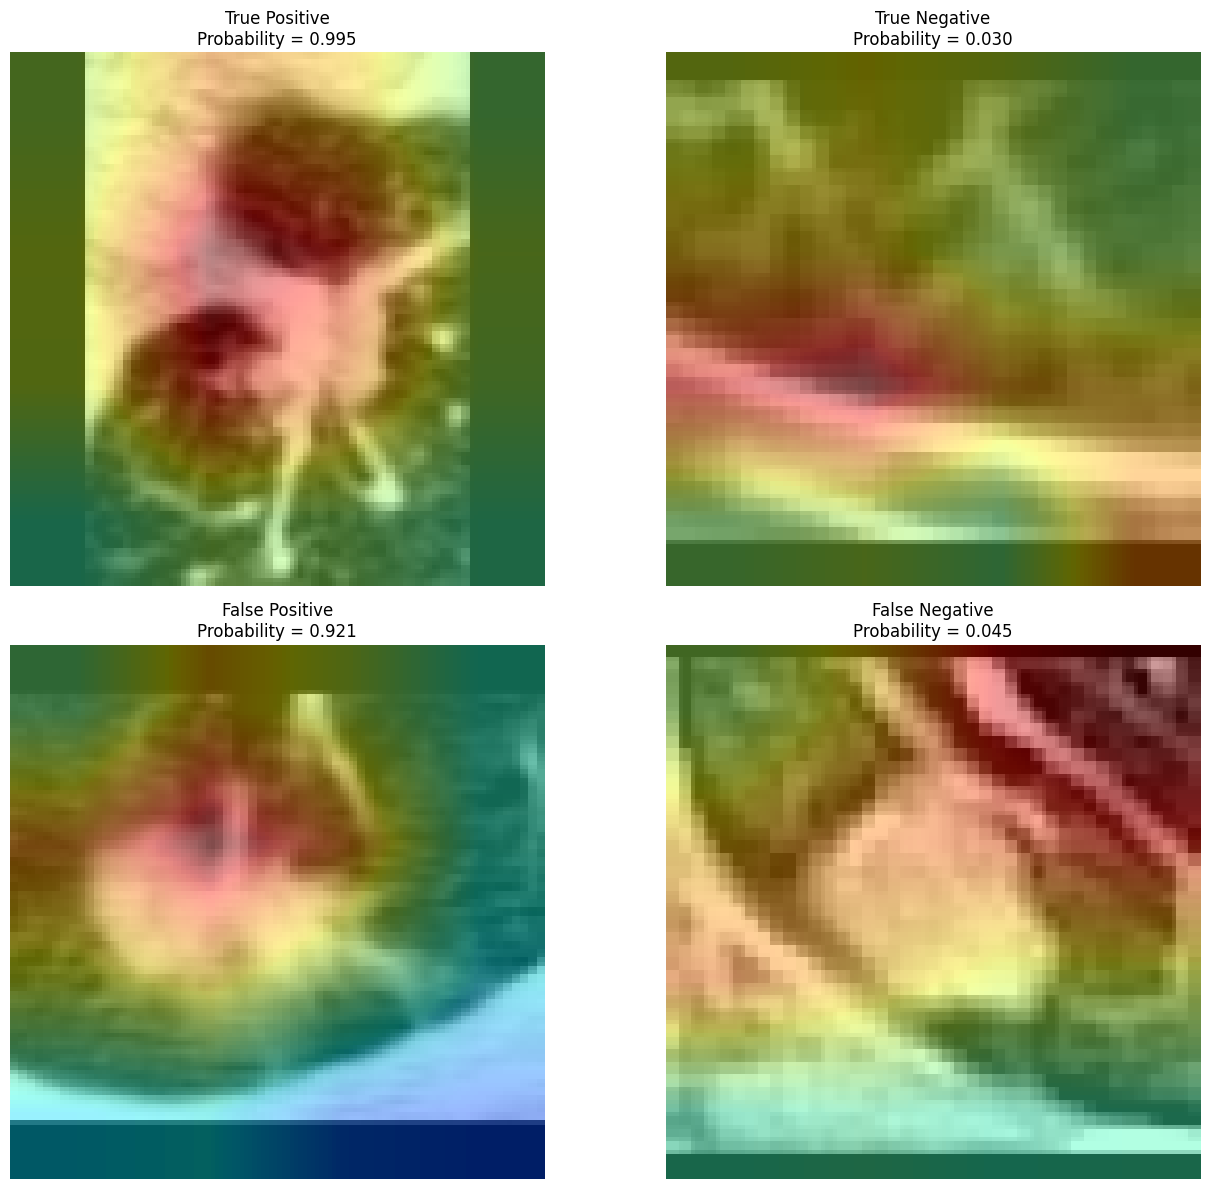

Saved representative Grad-CAM panel:
/content/drive/MyDrive/Dissertation/Models/Model_Comparison/GradCAM_EfficientNetB0/gradcam_representative_panel.png


In [163]:
# ============================================================
# Dissertation Grad-CAM Panel
# ============================================================

plt.figure(
    figsize=(14, 12)
)

plot_index = 1

for _, row in representative_cases_df.iterrows():

    image = load_single_image(
        row["ImagePath"]
    )

    image_batch = tf.expand_dims(
        image,
        axis=0
    )

    heatmap = make_gradcam_heatmap(
    image_batch=image_batch,
    model=efficientnet_model,
    backbone=efficientnet_backbone,
    feature_extractor=backbone_feature_extractor,
    target_class=int(row["PredictedLabel"])
    )

    _, _, overlay = create_gradcam_overlay(
        image=image,
        heatmap=heatmap,
        alpha=0.4
    )

    plt.subplot(
        2,
        2,
        plot_index
    )

    plt.imshow(
        overlay
    )

    plt.title(
        f"{row['Outcome']}\n"
        f"Probability = "
        f"{row['PredictedProbability']:.3f}"
    )

    plt.axis(
        "off"
    )

    plot_index += 1

plt.tight_layout()

GRADCAM_PANEL_PATH = (
    GRADCAM_ROOT
    / "gradcam_representative_panel.png"
)

plt.savefig(
    GRADCAM_PANEL_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved representative Grad-CAM panel:"
)

print(
    GRADCAM_PANEL_PATH
)

##31. Final notebook summary

In [164]:
# ============================================================
# Notebook 14 Summary
# ============================================================

print("=" * 70)
print("GRAD-CAM EXPLAINABILITY SUMMARY")
print("=" * 70)

print(
    "Final architecture:",
    final_selection["FinalArchitecture"]
)

print(
    "Selected configuration:",
    final_selection[
        "SelectedConfiguration"
    ]
)

print(
    "Grad-CAM layer:",
    LAST_CONV_LAYER_NAME
)

print(
    "Validation-selected F1 threshold:",
    EFFICIENTNET_F1_THRESHOLD
)

print(
    "Total test images:",
    len(
        gradcam_test_df
    )
)

print(
    "\nPrediction outcome counts:"
)

print(
    gradcam_test_df[
        "Outcome"
    ]
    .value_counts()
)

print(
    "\nRepresentative Grad-CAM images saved:",
    len(
        gradcam_metadata_df
    )
)

print(
    "\nOutput directory:"
)

print(
    GRADCAM_ROOT
)

GRAD-CAM EXPLAINABILITY SUMMARY
Final architecture: EfficientNetB0
Selected configuration: Fine-Tuned EfficientNetB0
Grad-CAM layer: top_conv
Validation-selected F1 threshold: 0.46439537
Total test images: 256

Prediction outcome counts:
Outcome
True Negative     205
True Positive      20
False Positive     16
False Negative     15
Name: count, dtype: int64

Representative Grad-CAM images saved: 12

Output directory:
/content/drive/MyDrive/Dissertation/Models/Model_Comparison/GradCAM_EfficientNetB0
